# Lecture 7c — Is it reading, or remembering?

**25882 AI-powered Investment and Risk Management**

---

### The question

> **How would you know whether your model's apparent skill is comprehension of the
> text in front of it, or memory of what happened next?**

A dictionary cannot cheat. It was fixed in 2011 and knows nothing about any company.
A large language model trained on years of financial commentary is a different
proposition: when you ask it whether a 2019 headline is good news, it may be
recalling the 2019 share price rather than reading the sentence.

Glasserman and Lin (2024) separate this into two distinct contaminations, and their
test is simple enough to run in an afternoon.

### What you will do

| Part | What it establishes |
| --- | --- |
| A | An anonymisation diagnostic, and why its **null result** on a dictionary is the thing that makes it trustworthy |
| B | What signal decay looks like, and how to measure a half-life |
| C | What a decaying signal is actually worth building — the lecture's closing question, as arithmetic |
| D | A reproducibility record you can attach to any scoring run |

### Running this notebook

Parts B, C and D need nothing but `numpy`. Part A needs the PhraseBank from Lec07a.

In [14]:
# --- setup -------------------------------------------------------------
import sys, subprocess, warnings, json, re
warnings.filterwarnings("ignore")
for pkg, mod in [("pysentiment2", "pysentiment2"),
                 ("vaderSentiment", "vaderSentiment"), ("plotly", "plotly")]:
    try:
        __import__(mod)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import airm7

pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 100)
print("ready")

ready


## Part A — The anonymisation test

Glasserman and Lin distinguish two ways a language model can appear skilful without
reading anything:

| Contamination | Mechanism |
| --- | --- |
| **Look-ahead bias** | the model has specific knowledge of the returns that followed *this* article |
| **Distraction** | the model's general knowledge *about the named company* interferes with its reading of the text |

The second is the one people do not expect, and in their study it was the larger
effect: anonymised headlines actually **performed better** than named ones.

The test is one substitution. Replace every company name with a neutral placeholder,
re-score, and compare.

In [16]:
for i, name in enumerate(airm7.FIRM_NAMES, start=1):
    print(f"{i:2d}. {name}")

 1. Nokia
 2. Nokian Tyres
 3. Outokumpu
 4. Cargotec
 5. Ruukki
 6. Rautaruukki
 7. Kesko
 8. Stora Enso
 9. UPM-Kymmene
10. UPM
11. Elcoteq
12. Neste Oil
13. Neste
14. Sanoma
15. Metso
16. Wartsila
17. Konecranes
18. Aspocomp
19. Talvivaara
20. Tieto
21. TietoEnator
22. Fortum
23. YIT
24. Amer Sports
25. Huhtamaki
26. Finnair
27. Kemira
28. Orion
29. Poyry
30. Vaisala
31. Uponor
32. Raisio
33. Atria
34. Componenta
35. Okmetic
36. Ahlstrom
37. Alma Media
38. Basware
39. Biohit
40. Cramo
41. Digia
42. Efore
43. Ekokem
44. Elisa
45. Etteplan
46. Exel
47. Finnlines
48. Glaston
49. HKScan
50. Honkarakenne
51. Ilkka
52. Incap
53. Kemppi
54. Kone
55. Lassila
56. Lemminkainen
57. Marimekko
58. Martela
59. Munksjo
60. Nordea
61. Nurminen Logistics
62. Olvi
63. Oriola
64. Outotec
65. Panostaja
66. PKC Group
67. Pohjola
68. Ramirent
69. Rapala
70. Sampo
71. Scanfil
72. Solteq
73. Sponda
74. SRV
75. Stockmann
76. Suominen
77. Tallink
78. Technopolis
79. Tecnotree
80. Teleste
81. Tikkurila
82. Tr

In [17]:
pb = airm7.load_phrasebank(agreement=50)
print()

# How many sentences does our curated name list actually reach?
hits = pb["sentence"].apply(
    lambda t: any(re.search(rf"\b{re.escape(n)}\b", t) for n in airm7.FIRM_NAMES))
print(f"Sentences containing a name from the curated list: "
      f"{hits.sum():,} of {len(pb):,}  ({hits.mean():.1%})")

  PhraseBank: 4,838 sentences at agreement >= 50

Sentences containing a name from the curated list: 1,403 of 4,838  (29.0%)


<details>
<summary><strong>Understanding the Regular Expression (click to expand)</strong></summary>

The expression

```python
re.search(rf"\b{re.escape(n)}\b", t)
```

checks whether a company name `n` appears in a sentence `t`.

**What are we trying to do?**

Suppose we have:

```python
n = "Nokia"
t = "Nokia shares rose sharply today."
```

We would like to detect that the sentence mentions the company **Nokia**.

`re.search(...)`

```python
re.search(pattern, text)
```

searches a piece of text for a specified pattern.

For example:

```python
re.search("Nokia", "Nokia shares rose sharply")
```

finds a match because the word *Nokia* appears in the text.

`re.escape(n)`

Company names sometimes contain characters that have special meanings in regular expressions.

For example:

```python
re.search("A.B", "ACB")
```

matches because `.` means "any character" in a regular expression.

To ensure that company names are treated as ordinary text, we use:

```python
re.escape(n)
```

For example:

```python
re.escape("A.B")
```

becomes

```python
A\.B
```

so the dot is interpreted literally rather than as a wildcard.

`\b` (word boundaries)

```python
\b
```

represents a **word boundary**.

This ensures that we match a complete company name rather than part of a longer word.

For example:

```python
re.search(r"Nokia", "Nokian Tyres")
```

returns a match because `"Nokia"` appears at the beginning of `"Nokian"`.

However:

```python
re.search(r"\bNokia\b", "Nokian Tyres")
```

does **not** match.

The word boundaries require *Nokia* to appear as a complete word.

| Text | Pattern `\bNokia\b` | Match? |
|--------|--------|--------|
| Nokia shares fell today | ✅ | Yes |
| Nokia announced earnings | ✅ | Yes |
| Nokian Tyres surged | ❌ | No |
| SuperNokia stock | ❌ | No |

**Building the pattern dynamically**

If

```python
n = "Nokia"
```

then

```python
rf"\b{re.escape(n)}\b"
```

becomes

```python
r"\bNokia\b"
```

If

```python
n = "Nokian Tyres"
```

it becomes

```python
r"\bNokian\ Tyres\b"
```

The expression automatically adapts to whichever company name is being checked.

`any(...)`

The code

```python
any(
    re.search(rf"\b{re.escape(n)}\b", t)
    for n in airm7.FIRM_NAMES
)
```

asks:

> Does at least one company name from our curated list appear in this sentence?

The moment a match is found, `any()` returns `True`.

**Putting it all together**

The expression

```python
re.search(rf"\b{re.escape(n)}\b", t)
```

- searches sentence `t`,
- treats company name `n` as ordinary text,
- matches only complete company names using word boundaries,
- and avoids false positives such as matching **Nokia** inside **Nokian**.

This allows us to estimate how many sentences mention at least one company from our curated list.
</details>

### A1. A curated list is not enough — and admitting that is part of the method

`airm7.FIRM_NAMES` is a hand-written list. It will miss firms, and the miss rate is
itself a measurement you should report, not a detail to hide.

A cheap complement is a **capitalised-token heuristic**: any capitalised word that is
not at the start of a sentence and is not a common word is a candidate entity. It
over-fires — it will catch months, countries and product names — and comparing the two
approaches tells you how much of your corpus you are actually anonymising.

In [18]:
STOP = {"The","A","An","In","On","At","For","And","But","Or","If","It","This","That",
        "We","They","He","She","There","However","Also","Its","Their","As","By","Of",
        "January","February","March","April","May","June","July","August","September",
        "October","November","December","Monday","Tuesday","Wednesday","Thursday",
        "Friday","Saturday","Sunday","EUR","USD","GBP","Finland","Sweden","Norway",
        "Denmark","Helsinki","Stockholm","Europe","European","Group","Oyj","Plc",
        "Nasdaq","OMX","CEO","CFO","EBIT","Q1","Q2","Q3","Q4"}

def candidate_entities(text: str) -> list[str]:
    '''Capitalised tokens after the first position, minus an obvious stop list.'''
    toks = str(text).split()
    return [t.strip(".,;:()'\"") for i, t in enumerate(toks)
            if i > 0 and t[:1].isupper() and t.strip(".,;:()'\"") not in STOP
            and len(t.strip(".,;:()'\"")) > 2 and not t.strip(".,;:()'\"").isupper()]

cands = pb["sentence"].apply(candidate_entities)
print(f"Sentences with at least one candidate entity: "
      f"{(cands.str.len() > 0).mean():.1%}")
print("\nMost frequent candidates (inspect these — the heuristic over-fires):")
print(pd.Series([e for lst in cands for e in lst]).value_counts().head(15).to_string())

Sentences with at least one candidate entity: 61.8%

Most frequent candidates (inspect these — the heuristic over-fires):
Finnish        287
Corporation    121
Nokia          110
Bank            94
Russia          81
Ltd             57
Board           55
China           50
Nordic          49
News            47
Company         45
Baltic          43
Swedish         40
Corp            39
Enso            38


### A2. Anonymise, then re-score

We use the **union** of both approaches: the curated list catches multi-word names the
heuristic splits, the heuristic catches firms we never listed. Over-firing is the
safer error here — replacing a country name with "the company" makes a sentence odd,
but it does not leak identity, which is the thing we are trying to remove.

In [20]:
def anonymise_hybrid(text: str) -> str:
    out = airm7.anonymise(text)                       # curated, longest-first
    for e in candidate_entities(out):
        out = re.sub(rf"\b{re.escape(e)}\b", "the company", out)
    out = re.sub(r"(the company[\s,]*){2,}", "the company ", out)   # collapse runs
    return out.strip()

pb = pb.copy()
pb["anon"] = pb["sentence"].map(anonymise_hybrid)
changed = (pb["anon"] != pb["sentence"])
print(f"Sentences altered by anonymisation: {changed.mean():.1%}\n")

for _, r in pb[changed].head(4).iterrows():
    print(f"  before: {r['sentence'][:210]}")
    print(f"  after : {r['anon'][:210]}\n")

Sentences altered by anonymisation: 65.0%

  before: ( ADP News ) - Dec 11 , 2008 - Finnish construction and engineering company Outotec Oyj ( OMX : OTE1V ) said today it won a EUR 28 million ( USD 36.8 m ) order to expand the phosphate concentrator in Siilinjarv
  after : ( ADP the company ) - the company 11 , 2008 - the company construction and engineering company the company Oyj ( OMX : OTE1V ) said today it won a EUR 28 million ( USD 36.8 m ) order to expand the phosphate con

  before: ( ADP News ) - Feb 11 , 2009 - Finnish management software solutions provider Ixonos Oyj ( HEL : XNS1V ) said today its net profit rose to EUR 3.5 million ( USD 4.5 m ) for 2008 from EUR 3.1 million for 2007 .
  after : ( ADP the company ) - the company 11 , 2009 - the company management software solutions provider the company Oyj ( HEL : XNS1V ) said today its net profit rose to EUR 3.5 million ( USD 4.5 m ) for 2008 from EUR

  before: ( ADP News ) - Feb 11 , 2009 - Finnish wood products technolog

### A3. Predict before you measure

**Write down your answer before running the next cell.**

For the Loughran–McDonald dictionary, what do you expect the accuracy gap between
named and anonymised sentences to be?

The dictionary has no representation of any company. It counts words from a fixed
list. "Nokia" is not on that list, and neither is "the company".

In [21]:
scorers = {"Loughran-McDonald": airm7.score_lm, "VADER": airm7.score_vader}
rows = []
for name, fn in scorers.items():
    a = airm7.accuracy(pb["label"], fn(pb["sentence"])["pred"])
    b = airm7.accuracy(pb["label"], fn(pb["anon"])["pred"])
    rows.append({"scorer": name, "named": a, "anonymised": b, "gap": b - a})

gaps = pd.DataFrame(rows)
print(gaps.round(4).to_string(index=False))

           scorer  named  anonymised    gap
Loughran-McDonald 0.5740      0.5829 0.0089
            VADER 0.5438      0.5550 0.0112


### A4. The null result is the point

The gap for a dictionary should be essentially zero — the only movement comes from
anonymisation incidentally deleting a sentiment-bearing word.

**That null is what makes the test worth running.** It is a placebo. We have shown
that the procedure does not manufacture a difference where none can exist, so if a
learned model *does* show a gap, we can attribute it to the model rather than to our
substitution code.

This is a habit worth generalising:

> Before you interpret a diagnostic, run it on something you know the answer for. A
> diagnostic that has never returned a null is not a diagnostic.

Now the same test on a model that *does* have memory. This is the stretch section: it
downloads FinBERT and skips cleanly if the network blocks it.

In [22]:
fin_named = airm7.score_finbert(pb["sentence"].tolist())
if fin_named is not None:
    fin_anon = airm7.score_finbert(pb["anon"].tolist())
    a = airm7.accuracy(pb["label"], fin_named["pred"])
    b = airm7.accuracy(pb["label"], fin_anon["pred"])
    print(f"\nFinBERT   named {a:.4f}   anonymised {b:.4f}   gap {b-a:+.4f}")

    moved = (fin_named["pred"].values != fin_anon["pred"].values)
    print(f"Predictions that changed when the name was removed: {moved.mean():.1%}")
    print("\nSentences where removing the name changed the call:\n")
    for i in np.where(moved)[0][:5]:
        print(f"  human={pb['label'].iloc[i]:<9s} "
              f"named={fin_named['pred'].iloc[i]:<9s} anonymised={fin_anon['pred'].iloc[i]}")
        print(f"    {pb['sentence'].iloc[i][:120]}\n")
else:
    print("\nSkipped. The dictionary placebo above is the transferable lesson.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


FinBERT   named 0.8896   anonymised 0.8871   gap -0.0025
Predictions that changed when the name was removed: 2.6%

Sentences where removing the name changed the call:

  human=neutral   named=positive  anon=neutral
    According to Finnair Technical Services , the measure is above all due to the employment situation .

  human=neutral   named=neutral   anon=positive
    Amanda said that it had already made a USD5 .0 m investment commitment in Russia Partners II fund in July 2005 .

  human=neutral   named=neutral   anon=positive
    BioTie North-American licensing partner Somaxon Pharmaceuticals started a phase II-III clinical study in patients suffer

  human=negative  named=negative  anon=neutral
    Cash flow after investments amounted to EUR45m , down from EUR46m .

  human=neutral   named=positive  anon=neutral
    F-Secure , a developer of security solutions as a service through Internet Service Providers and mobile operators , anno



### A5. What this does and does not prove

Even a large gap would not, on this corpus, separate look-ahead bias from distraction.
The PhraseBank has no dates and no returns, so there is nothing for the model to have
looked ahead *to*. Any gap here is distraction alone.

To isolate look-ahead bias you need dated text and the subsequent returns, and you
need your sample to begin **after the model's stated knowledge cutoff**. That is the
design Lopez-Lira and Tang use: GPT-4's cutoff is September 2021, their sample starts
in October 2021.

The awkward corollary: every time a provider updates a model, the cutoff moves
forward and a previously clean sample becomes contaminated. **Pin the version.**

## Part B — Signals decay

An edge that exists is not an edge that persists. As more capital acts on the same
information, prices incorporate it faster, and what is left for a late arrival
shrinks.

We simulate adoption as a logistic curve and let the available edge fall with it,
towards a small residual floor rather than to exactly zero.

<details>
<summary><b>The maths (click to expand)</b></summary>

Adoption $a_t$ follows a logistic path to capacity $\bar a$, and the edge available
to a late arriver is the part not yet priced, plus a floor $f$:

$$a_t = \frac{\bar a}{1+e^{\,k - gt}}, \qquad
\text{edge}_t = \text{edge}_0\left[f + (1-f)\left(1 - \frac{a_t}{\bar a}\right)\right]$$

Daily returns are $r_t = \text{edge}_t + \sigma u_t$, so the annualised Sharpe ratio
in year $y$ is approximately $\overline{\text{edge}}_y \sqrt{252}/\sigma$.

The parameters were **not** fitted to any published result. They were chosen to give
a plausible shape — a signal that halves roughly every 18 months — so that the
comparison with the published path below is a comparison, not a tautology.

</details>

In [23]:
decay = airm7.simulate_adoption_decay()

annual = (decay.groupby("year")
               .agg(sharpe=("ret", airm7.sharpe),
                    mean_edge_bp=("edge", lambda s: s.mean() * 1e4),
                    adoption=("adoption", "mean")))
print(annual.round(3).to_string())

hl = airm7.half_life(annual["sharpe"])
print(f"\nImplied half-life of the Sharpe ratio: {hl:.2f} years")

      sharpe  mean_edge_bp  adoption
year                                
1      5.587        34.241     0.202
2      4.164        25.212     0.438
3      2.597        15.722     0.685
4      1.265        10.077     0.832

Implied half-life of the Sharpe ratio: 1.41 years


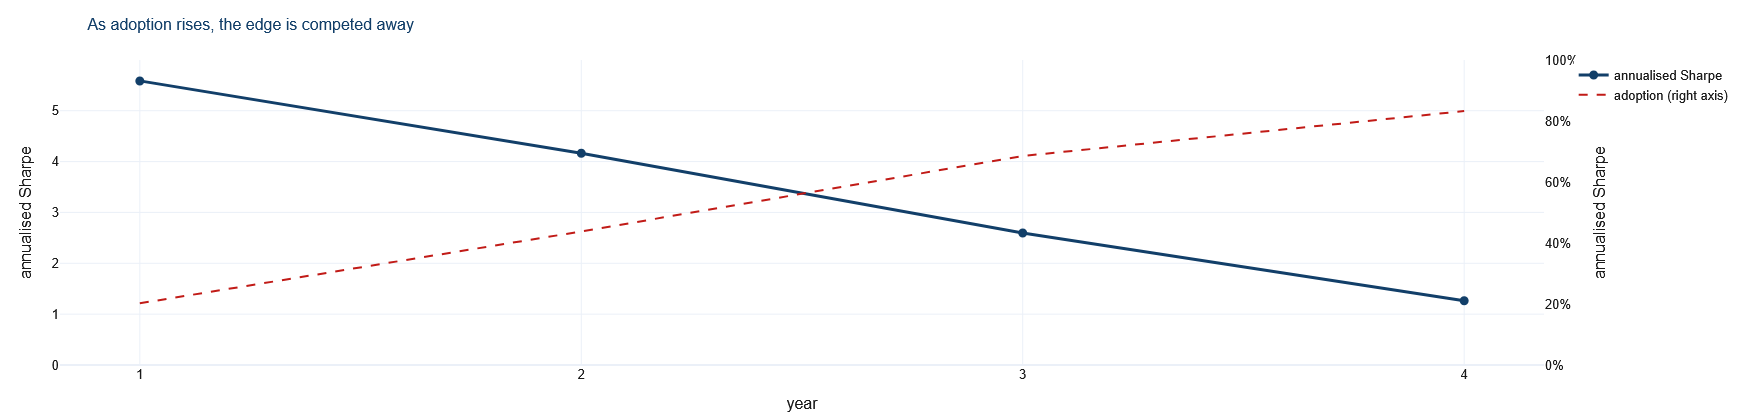

In [24]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=annual.index, y=annual["sharpe"], mode="lines+markers",
                         name="annualised Sharpe", line=dict(color=airm7.NAVY, width=3),
                         marker=dict(size=9)))
fig.add_trace(go.Scatter(x=annual.index, y=annual["adoption"],
                         mode="lines", name="adoption (right axis)",
                         line=dict(color=airm7.RED, width=2, dash="dash"),
                         yaxis="y2"))
fig.update_layout(yaxis2=dict(overlaying="y", side="right", showgrid=False,
                              title="adoption", range=[0, 1],
                              tickformat=".0%"))
fig.update_xaxes(title_text="year", dtick=1)
fig.update_yaxes(title_text="annualised Sharpe", rangemode="tozero")
airm7.fig_layout(fig, "As adoption rises, the edge is competed away", height=420).show()

### B1. Compare with what was actually observed

Lopez-Lira and Tang report the annualised Sharpe ratio of their GPT-4 headline
strategy falling **6.54 → 3.68 → 2.33 → 1.22**. Their explanation is not that the
model degraded; it is that the market got faster as LLM adoption spread.

Compute the half-life implied by their published path and compare it with ours.

In [25]:
published = pd.Series([6.54, 3.68, 2.33, 1.22], index=[1, 2, 3, 4], name="published")
hl_pub = airm7.half_life(published)

comp = pd.DataFrame({"simulated": annual["sharpe"].round(2), "published": published})
print(comp.to_string())
print(f"\nhalf-life, simulated : {hl:.2f} years")
print(f"half-life, published : {hl_pub:.2f} years")
print("\nYear-on-year ratios:")
print(pd.DataFrame({"simulated": (annual['sharpe'].shift(-1)/annual['sharpe']).round(2),
                    "published": (published.shift(-1)/published).round(2)}).dropna().to_string())

   simulated  published
1       5.59       6.54
2       4.16       3.68
3       2.60       2.33
4       1.26       1.22

half-life, simulated : 1.41 years
half-life, published : 1.26 years

Year-on-year ratios:
   simulated  published
1       0.75       0.56
2       0.62       0.63
3       0.49       0.52


The levels differ — ours starts lower — but the **shape** is the same, and the
half-lives are within a few months of each other. A mechanism as crude as "logistic
adoption eats the edge" reproduces the decay profile of a real published strategy.

That should change how you read any backtest. A full-sample Sharpe ratio for a
strategy over a period in which it was being adopted is an **average over a decaying
path**, and it will systematically overstate what is available to you now.

## Part C — What is a decaying signal worth building?

The lecture closed with a question: *if a signal's edge halves every year, what is the
correct amount to spend building it?*

That is not rhetorical. It is a present-value calculation, and it is short.

<details>
<summary><b>The maths (click to expand)</b></summary>

Run capital $K$ at target volatility $\sigma_{\text{tgt}}$. In year $y$ the strategy's
gross P&L is approximately

$$\Pi_y \;=\; \text{Sharpe}_y \times \sigma_{\text{tgt}} \times K$$

Net of a running cost $c$ (data licences, infrastructure, people) and discounted at
$r$, the project is worth

$$\text{NPV} \;=\; \sum_{y=1}^{Y}\frac{\Pi_y - c}{(1+r)^{y}} \;-\; C_{\text{build}}$$

The break-even build cost is the value of $C_{\text{build}}$ that sets NPV to zero.

</details>

In [26]:
K          = 250e6      # capital run on the signal, USD
SIGMA_TGT  = 0.08       # target annualised volatility of the sleeve
RUN_COST   = 1.2e6      # data licence + infrastructure + people, per year
DISCOUNT   = 0.10

pnl = annual["sharpe"] * SIGMA_TGT * K
cash = pnl - RUN_COST
disc = cash / (1 + DISCOUNT) ** annual.index
breakeven = disc.sum()

table = pd.DataFrame({
    "sharpe": annual["sharpe"].round(2),
    "gross_pnl_$m": (pnl / 1e6).round(2),
    "net_cash_$m": (cash / 1e6).round(2),
    "discounted_$m": (disc / 1e6).round(2),
})
print(table.to_string())
print(f"\nBreak-even build cost: ${breakeven/1e6:,.1f}m")
print(f"  of which year 1 alone: ${disc.iloc[0]/1e6:,.1f}m "
      f"({disc.iloc[0]/breakeven:.0%})")
print(f"  years 3 and 4 combined: ${disc.iloc[2:].sum()/1e6:,.1f}m "
      f"({disc.iloc[2:].sum()/breakeven:.0%})")

      sharpe  gross_pnl_$m  net_cash_$m  discounted_$m
year                                                  
1       5.59        111.74       110.54         100.49
2       4.16         83.29        82.09          67.84
3       2.60         51.94        50.74          38.12
4       1.26         25.29        24.09          16.45

Break-even build cost: $222.9m
  of which year 1 alone: $100.5m (45%)
  years 3 and 4 combined: $54.6m (24%)


### First, a sanity check on the inputs

Before drawing any conclusion from that number, look at what we fed it. A Sharpe
ratio of 5.6 is a **paper-portfolio** figure: gross of transaction costs, gross of
borrow, gross of market impact, and assuming you can hold the whole book at target
size. Published headline Sharpes in this literature almost always are.

Plugging a paper Sharpe into a business case is exactly the error the lecture warned
about with the 90% hit rate you cannot trade. Apply a haircut and re-run.

In [27]:
HAIRCUT = 0.25          # realised / paper. 0.2-0.3 is a defensible planning number.

real_sharpe = annual["sharpe"] * HAIRCUT
pnl_r = real_sharpe * SIGMA_TGT * K
cash_r = pnl_r - RUN_COST
disc_r = cash_r / (1 + DISCOUNT) ** annual.index

print(pd.DataFrame({
    "paper_sharpe": annual["sharpe"].round(2),
    "realised_sharpe": real_sharpe.round(2),
    "net_cash_$m": (cash_r / 1e6).round(2),
    "discounted_$m": (disc_r / 1e6).round(2),
}).to_string())

print(f"\nBreak-even build cost, paper    : ${breakeven/1e6:,.1f}m")
print(f"Break-even build cost, haircut  : ${disc_r.sum()/1e6:,.1f}m")
print(f"                       ratio    : {disc_r.sum()/breakeven:.2f}")

neg = cash_r[cash_r < 0]
if len(neg):
    print(f"\nNet cash turns NEGATIVE in year {neg.index[0]} - "
          f"the running cost exceeds the P&L while the signal is still 'working'.")
else:
    print("\nNet cash stays positive over the modelled horizon.")

      paper_sharpe  realised_sharpe  net_cash_$m  discounted_$m
year                                                           
1             5.59             1.40        26.73          24.30
2             4.16             1.04        19.62          16.22
3             2.60             0.65        11.78           8.85
4             1.26             0.32         5.12           3.50

Break-even build cost, paper    : $222.9m
Break-even build cost, haircut  : $52.9m
                       ratio    : 0.24

Net cash stays positive over the modelled horizon.


A realised Sharpe of 1.4 falling to 0.3 is a recognisable object. A break-even build
budget in the tens of millions is a number you could defend to a committee. The
$223m version was never real.

Notice that the haircut does **not** scale the answer by exactly 0.25: the running
cost is fixed, so it eats a growing share of a shrinking P&L. Push the horizon out
far enough, or raise `RUN_COST`, and net cash turns negative while the Sharpe ratio
is still positive — a signal that is working and losing money at the same time. Core
exercise 3 asks you to find that crossing point and write the trigger for it.

### The answer, and the uncomfortable part

Look at how the value is distributed across time. The overwhelming majority sits in
the first year or two, because that is where the Sharpe ratio is.

Three consequences follow, and none of them is about modelling:

1. **Time to market dominates model quality.** A signal delivered six months late
   loses a large share of its lifetime value. Spending those six months improving
   accuracy from 0.72 to 0.75 is very unlikely to be worth it.
2. **A long build is self-defeating.** If the build takes as long as the half-life,
   the thing you deploy is not the thing you evaluated.
3. **The run cost matters more each year.** As the edge decays towards the floor,
   the fixed data licence eventually exceeds the P&L — and the decommissioning
   decision needs a trigger set in advance, not a discussion once it is losing money.

Change `K`, `RUN_COST` and the half-life and watch which of these bites first.

## Part D — The reproducibility record

Every scoring run in this notebook should be reconstructible a year from now. The
lecture's appendix gave a minimal template; here it is as an artefact you can attach
to a results file.

The important discipline is not the format. It is that **a blank field is a caveat you
owe the reader.**

In [28]:
import platform, datetime

def scoring_record(scorer, unit, aggregation, **extra):
    rec = {
        "scorer": scorer,
        "accessed_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
        "temperature": None,          # not applicable to a deterministic scorer
        "prompt_id": None,            # not applicable
        "knowledge_cutoff": None,     # <-- MUST be filled for any LLM scorer
        "sample_start": None,
        "unit_of_observation": unit,
        "relevance_rule": "none - every sentence scored",
        "aggregation": aggregation,
        "corpus": "Financial PhraseBank (Malo et al. 2014), CC BY-NC-SA 3.0",
        "n_items": int(len(pb)),
        "python": platform.python_version(),
        "raw_output_path": None,
    }
    rec.update(extra)
    return rec

rec = scoring_record(
    scorer="pysentiment2.LM (Loughran-McDonald word lists)",
    unit="sentence",
    aggregation="none - sentence-level classification, band=0.10",
    deterministic=True,
)
print(json.dumps(rec, indent=2))

blank = [k for k, v in rec.items() if v is None]
print(f"\n{len(blank)} field(s) left blank: {blank}")
print("For a dictionary these are genuinely not applicable.")
print("For an LLM scorer, a blank 'knowledge_cutoff' means you cannot rule out")
print("look-ahead bias, and the result needs that caveat stated explicitly.")

{
  "scorer": "pysentiment2.LM (Loughran-McDonald word lists)",
  "accessed_utc": "2026-08-27T02:38:26+00:00",
  "temperature": null,
  "prompt_id": null,
  "knowledge_cutoff": null,
  "sample_start": null,
  "unit_of_observation": "sentence",
  "relevance_rule": "none - every sentence scored",
  "aggregation": "none - sentence-level classification, band=0.10",
  "corpus": "Financial PhraseBank (Malo et al. 2014), CC BY-NC-SA 3.0",
  "n_items": 4838,
  "python": "3.13.14",
  "raw_output_path": null,
  "deterministic": true
}

5 field(s) left blank: ['temperature', 'prompt_id', 'knowledge_cutoff', 'sample_start', 'raw_output_path']
For a dictionary these are genuinely not applicable.
For an LLM scorer, a blank 'knowledge_cutoff' means you cannot rule out
look-ahead bias, and the result needs that caveat stated explicitly.


## Exercises

### Core

1. **Placebo the placebo.** Replace company names with *another company's* name
   rather than a neutral placeholder. If a scorer is genuinely reading the text, this
   should change nothing. Does it?
2. **Half-life sensitivity.** In Part C, vary the `growth` parameter of
   `simulate_adoption_decay` so the half-life ranges from 0.5 to 3 years. Plot
   break-even build cost against half-life. Is the relationship linear?
3. **Decommissioning trigger.** At what point does annual net cash go negative under
   the shipped parameters? Write the monitoring rule you would put in front of a risk
   committee — as a threshold on an observable, not a judgement call.

### Stretch

4. **Proper NER.** Swap the capitalised-token heuristic for `spacy` with
   `en_core_web_sm`, keeping only `ORG` entities. How much does the anonymisation
   rate change, and does the measured gap change with it?
5. **Adoption from data.** Our adoption curve is assumed. Propose an observable proxy
   for the adoption of a public signal — and say what confound would make it a bad
   proxy.
6. **Both contaminations at once.** Design an experiment that would separate
   look-ahead bias from distraction. You need dated text, subsequent returns, and a
   model whose cutoff falls inside your sample. Write the design, state what each arm
   controls for, and be explicit about what you would conclude from each of the four
   possible outcome patterns.

---

## Where the three notebooks leave you

| Notebook | The question it answered |
| --- | --- |
| 7a | Scorers fail on the same sentences humans find hard, so ensembling will not save you |
| 7b | You can compute, in one line and before any regression, how much an omitted attention control will move your coefficient |
| 7c | A diagnostic you have never seen return a null is not a diagnostic — and a decaying edge is worth less than its peak Sharpe suggests |

None of these is a fact about NLP. They are facts about **evaluation**, which is what
this subject is for.